# DenialOps AI — Data Load and EDA

This notebook loads the 2024 CMS Medicare Physician & Other Practitioners provider-service dataset, creates reimbursement-risk features, performs EDA, and builds a first proxy denial-risk label for later modeling.

**Important:** The CMS dataset does not include true claim-denial outcomes. The `denial_risk_proxy` target created in this notebook is a reimbursement-friction proxy, not an actual denial label.

## Setup

In [34]:
# Import core libraries and set display options for easier data inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("DenialOps AI environment ready")

DenialOps AI environment ready


In [35]:
# Define local project paths for raw and processed data

RAW_DATA_PATH = Path("../data/raw/medicare_provider_service_2024.csv")
PROCESSED_DATA_DIR = Path("../data/processed")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data path:", RAW_DATA_PATH)
print("Processed data folder:", PROCESSED_DATA_DIR)

Raw data path: ..\data\raw\medicare_provider_service_2024.csv
Processed data folder: ..\data\processed


## Load Raw Data

In [36]:
# Load the raw CMS Medicare provider-service dataset from the local data folder

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"File not found: {RAW_DATA_PATH}")

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(df.shape)
df.head()

(9781673, 28)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,HCPCS_Cd,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


In [37]:
# Inspect column names, data types, non-null counts, and memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9781673 entries, 0 to 9781672
Data columns (total 28 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   Rndrng_NPI                     int64  
 1   Rndrng_Prvdr_Last_Org_Name     object 
 2   Rndrng_Prvdr_First_Name        object 
 3   Rndrng_Prvdr_MI                object 
 4   Rndrng_Prvdr_Crdntls           object 
 5   Rndrng_Prvdr_Ent_Cd            object 
 6   Rndrng_Prvdr_St1               object 
 7   Rndrng_Prvdr_St2               object 
 8   Rndrng_Prvdr_City              object 
 9   Rndrng_Prvdr_State_Abrvtn      object 
 10  Rndrng_Prvdr_State_FIPS        object 
 11  Rndrng_Prvdr_Zip5              object 
 12  Rndrng_Prvdr_RUCA              float64
 13  Rndrng_Prvdr_RUCA_Desc         object 
 14  Rndrng_Prvdr_Cntry             object 
 15  Rndrng_Prvdr_Type              object 
 16  Rndrng_Prvdr_Mdcr_Prtcptg_Ind  object 
 17  HCPCS_Cd                       object 
 18  HC

In [38]:
# Display all column names so we can decide which fields are useful for the project

df.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI',
       'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
       'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs',
       'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt'],
      dtype='object')

## Select and Clean Columns

In [39]:
# Select the columns needed for reimbursement-risk analysis and future denial-risk modeling

useful_cols = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_Type",
    "Rndrng_Prvdr_Mdcr_Prtcptg_Ind",
    "HCPCS_Cd",
    "HCPCS_Desc",
    "HCPCS_Drug_Ind",
    "Place_Of_Srvc",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Bene_Day_Srvcs",
    "Avg_Sbmtd_Chrg",
    "Avg_Mdcr_Alowd_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "Avg_Mdcr_Stdzd_Amt"
]

df_small = df[useful_cols].copy()

print(df_small.shape)
df_small.head()

(9781673, 15)


,Rndrng_NPI,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,HCPCS_Cd,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,MD,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,MD,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,MD,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,MD,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,MD,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


In [40]:
# Rename CMS columns into cleaner snake_case names for easier coding and readability

df_small.columns = [
    "provider_npi",
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "hcpcs_description",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount"
]

df_small.head()

,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount
0,1003000126,MD,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,MD,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,MD,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,MD,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,MD,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


In [41]:
# Check missing values before creating new features

missing_before = df_small.isna().sum().sort_values(ascending=False)

missing_before

provider_npi                        0
provider_state                      0
provider_type                       0
medicare_participating              0
hcpcs_code                          0
hcpcs_description                   0
is_drug                             0
place_of_service                    0
total_beneficiaries                 0
total_services                      0
total_beneficiary_day_services      0
avg_submitted_charge                0
avg_medicare_allowed_amount         0
avg_medicare_payment_amount         0
avg_medicare_standardized_amount    0
dtype: int64

In [42]:
# Check whether the selected dataset contains duplicate rows

duplicate_count = df_small.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [43]:
# Review summary statistics for numeric columns before creating new features

df_small.describe()

,provider_npi,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount
count,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06,9.781673e+06
mean,1.499356e+09,8.498743e+01,2.818193e+02,1.372579e+02,4.307621e+02,1.063680e+02,8.300478e+01,8.249464e+01
std,2.877017e+08,1.312172e+03,6.307908e+03,2.181447e+03,1.521585e+03,3.329877e+02,2.656162e+02,2.671587e+02
min,1.003000e+09,1.100000e+01,4.400000e+00,1.100000e+01,3.508770e-05,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.245947e+09,1.700000e+01,2.100000e+01,2.000000e+01,7.328125e+01,2.548538e+01,1.965000e+01,1.947113e+01
50%,1.497941e+09,3.200000e+01,4.300000e+01,4.100000e+01,1.800000e+02,7.155108e+01,5.245652e+01,5.265500e+01
75%,1.740789e+09,7.200000e+01,1.190000e+02,1.060000e+02,3.670000e+02,1.211388e+02,9.091222e+01,9.077629e+01
max,1.993000e+09,8.967620e+05,6.486401e+06,1.835261e+06,9.999999e+04,5.396543e+04,4.299489e+04,4.299489e+04


## Feature Engineering

In [44]:
# Create reimbursement-risk features using safe division to avoid infinite values

df_small["charge_to_allowed_ratio"] = np.where(
    df_small["avg_medicare_allowed_amount"] > 0,
    df_small["avg_submitted_charge"] / df_small["avg_medicare_allowed_amount"],
    np.nan
)

df_small["payment_to_charge_ratio"] = np.where(
    df_small["avg_submitted_charge"] > 0,
    df_small["avg_medicare_payment_amount"] / df_small["avg_submitted_charge"],
    np.nan
)

df_small["payment_to_allowed_ratio"] = np.where(
    df_small["avg_medicare_allowed_amount"] > 0,
    df_small["avg_medicare_payment_amount"] / df_small["avg_medicare_allowed_amount"],
    np.nan
)

df_small["services_per_beneficiary"] = np.where(
    df_small["total_beneficiaries"] > 0,
    df_small["total_services"] / df_small["total_beneficiaries"],
    np.nan
)

df_small.head()

,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary
0,1003000126,MD,Internal Medicine,Y,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389,3.596824,0.213901,0.769364,1.000000
1,1003000126,MD,Internal Medicine,Y,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133,2.787511,0.271670,0.757282,1.000000
2,1003000126,MD,Internal Medicine,Y,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365,4.602003,0.171302,0.788333,1.000000
3,1003000126,MD,Internal Medicine,Y,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250,2.553180,0.273086,0.697238,1.454545
4,1003000126,MD,Internal Medicine,Y,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857,7.167102,0.107485,0.770353,1.891892


In [45]:
# Check whether the new engineered features created missing values

engineered_cols = [
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "payment_to_allowed_ratio",
    "services_per_beneficiary"
]

df_small[engineered_cols].isna().sum()

charge_to_allowed_ratio     18
payment_to_charge_ratio      0
payment_to_allowed_ratio    18
services_per_beneficiary     0
dtype: int64

In [46]:
# Drop rows where engineered ratio features are missing after safe division

df_small = df_small.dropna(subset=engineered_cols)

print(df_small.shape)
df_small[engineered_cols].isna().sum()

(9781655, 19)


charge_to_allowed_ratio     0
payment_to_charge_ratio     0
payment_to_allowed_ratio    0
services_per_beneficiary    0
dtype: int64

## Create 250k Working Sample

In [47]:
# Create a 250,000-row sample for stronger EDA and modeling while keeping local runtime manageable

sample_size = 250_000
sample_df = df_small.sample(n=sample_size, random_state=42)

print(sample_df.shape)
sample_df.head()

(250000, 19)


,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary
81501,1003882531,UT,Family Practice,Y,77067,Screening mammography,N,O,11,11.0,11,325.660000,84.184545,84.184545,90.226364,3.868406,0.258504,1.000000,1.000000
9712682,1992254726,TX,Nurse Practitioner,Y,87804,Detection test by immunoassay with direct visu...,N,O,11,11.0,11,50.000000,16.220000,16.220000,16.220000,3.082614,0.324400,1.000000,1.000000
7413171,1750657938,PA,Emergency Medicine,Y,99285,Emergency department visit with high level of ...,N,F,51,51.0,51,1377.980392,172.981765,133.733333,130.515294,7.966044,0.097050,0.773107,1.000000
2010979,1205611712,FL,Nurse Practitioner,Y,99350,Residence visit for established patient with h...,N,O,56,75.0,75,180.900000,154.000000,122.700000,122.450000,1.174675,0.678275,0.796753,1.339286
290418,1023763927,MD,Physical Therapist in Private Practice,Y,97110,Therapy procedure using exercise to develop st...,N,O,77,917.0,811,75.000000,28.049662,21.247874,19.097012,2.673829,0.283305,0.757509,11.909091


In [48]:
# Save the 250k processed sample as a CSV file for future notebooks

sample_csv_path = PROCESSED_DATA_DIR / "medicare_provider_service_sample_250k.csv"

sample_df.to_csv(sample_csv_path, index=False)

print(f"Saved CSV sample to: {sample_csv_path}")

Saved CSV sample to: ..\data\processed\medicare_provider_service_sample_250k.csv


In [49]:
# Save the 250k processed sample as a Parquet file for faster loading later

sample_parquet_path = PROCESSED_DATA_DIR / "medicare_provider_service_sample_250k.parquet"

sample_df.to_parquet(sample_parquet_path, index=False)

print(f"Saved Parquet sample to: {sample_parquet_path}")

Saved Parquet sample to: ..\data\processed\medicare_provider_service_sample_250k.parquet


## Exploratory Data Analysis

In [50]:
# Identify the top 20 provider types by total Medicare services using the full cleaned dataset

top_provider_types = (
    df_small.groupby("provider_type")["total_services"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_provider_types

provider_type
Clinical Laboratory                       304353832.8
Diagnostic Radiology                      205360764.4
Hematology-Oncology                       204641019.2
Physical Therapist in Private Practice    171134158.0
Rheumatology                              163784256.0
Nurse Practitioner                        163487674.7
Ophthalmology                             149374584.7
Internal Medicine                         140258389.5
Ambulance Service Provider                115159154.9
Family Practice                           100314968.9
Physician Assistant                        80317800.0
Orthopedic Surgery                         68465531.7
Cardiology                                 59631172.2
Neurology                                  58039787.1
Medical Oncology                           53822577.1
Dermatology                                49081997.5
Ambulatory Surgical Center                 48421423.0
Urology                                    45061771.9
Infectious Dis

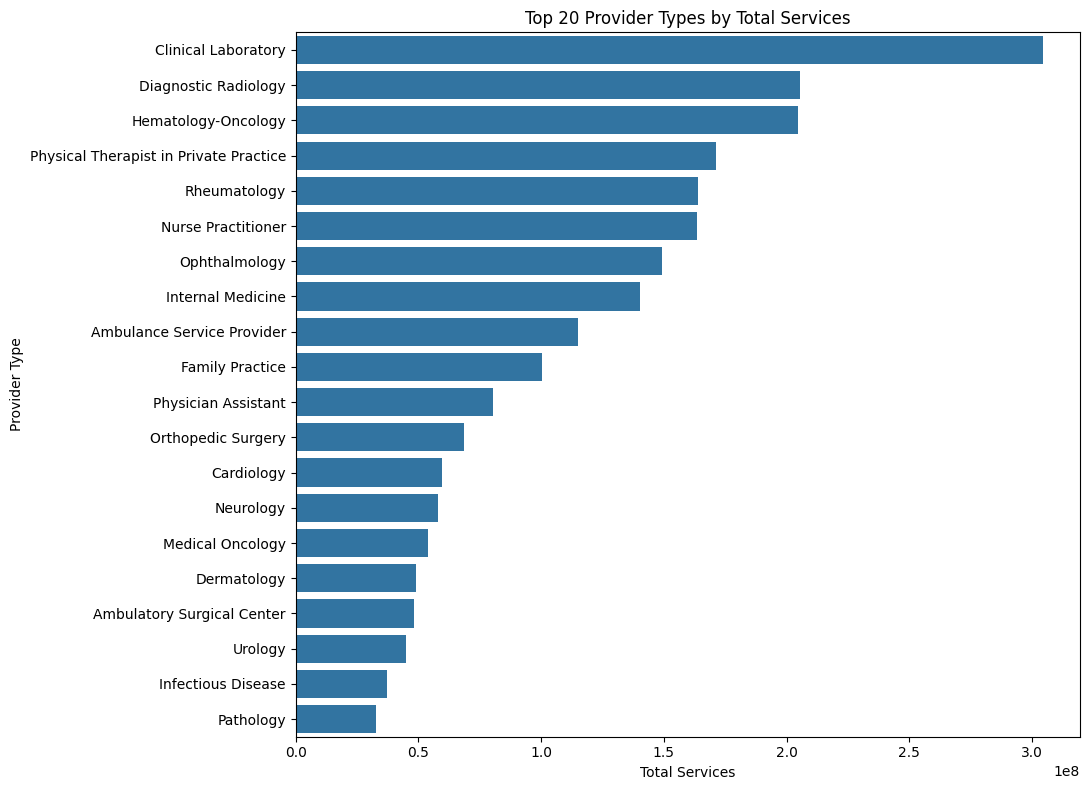

In [51]:
# Plot the top 20 provider types by total services using seaborn

plot_df = top_provider_types.reset_index()
plot_df.columns = ["provider_type", "total_services"]

plt.figure(figsize=(11, 8))
sns.barplot(data=plot_df, x="total_services", y="provider_type")

plt.title("Top 20 Provider Types by Total Services")
plt.xlabel("Total Services")
plt.ylabel("Provider Type")
plt.tight_layout()
plt.show()

In [52]:
# Identify provider types with the highest average submitted charges in the 250k sample

top_charge_specialties = (
    sample_df.groupby("provider_type")["avg_submitted_charge"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

top_charge_specialties

provider_type
Ambulatory Surgical Center                        7749.819428
Home Infusion Therapy Services                    5429.166667
Radiation Therapy Center                          2298.112254
All Other Suppliers                               2227.022125
Cardiac Surgery                                   1998.649867
Ambulance Service Provider                        1775.347745
Peripheral Vascular Disease                       1638.802925
Neurosurgery                                      1616.933768
Anesthesiology                                    1320.102129
Certified Registered Nurse Anesthetist (CRNA)     1312.363515
Thoracic Surgery                                  1277.844161
Vascular Surgery                                  1143.203705
Anesthesiology Assistant                          1128.211089
Independent Diagnostic Testing Facility (IDTF)    1045.420061
Orthopedic Surgery                                 889.339447
Radiation Oncology                                 827.1

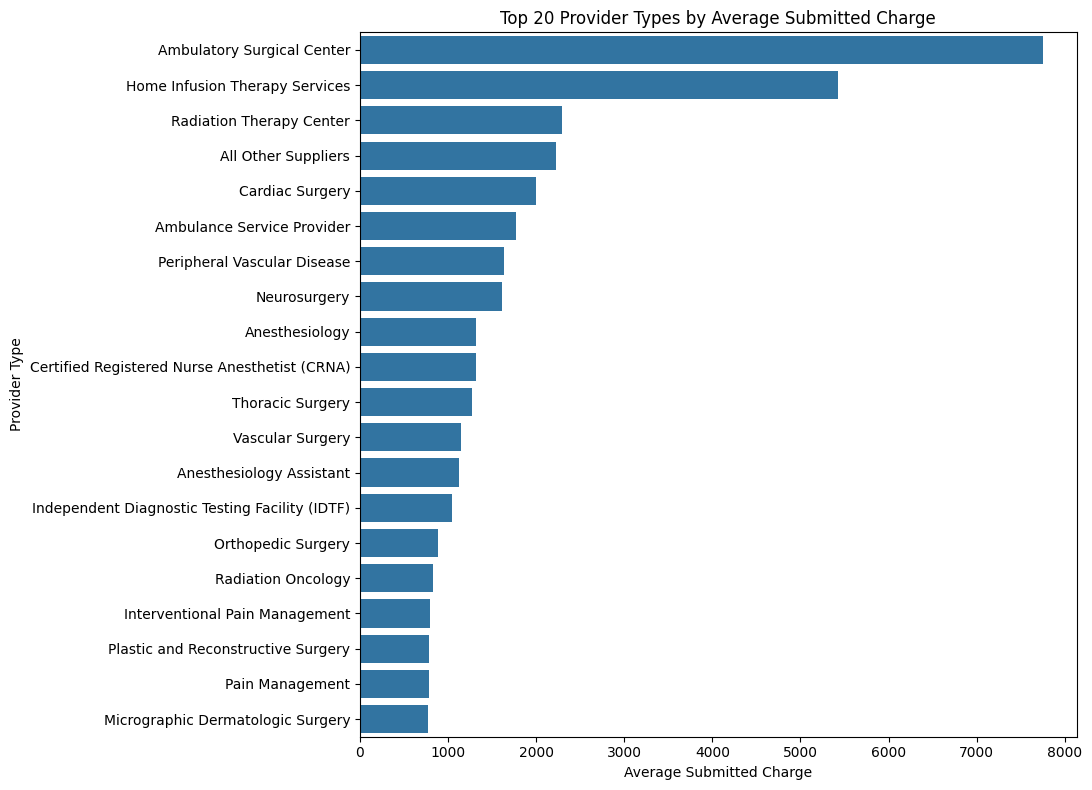

In [53]:
# Plot provider types with the highest average submitted charges using seaborn

plot_df = top_charge_specialties.reset_index()
plot_df.columns = ["provider_type", "avg_submitted_charge"]

plt.figure(figsize=(11, 8))
sns.barplot(data=plot_df, x="avg_submitted_charge", y="provider_type")

plt.title("Top 20 Provider Types by Average Submitted Charge")
plt.xlabel("Average Submitted Charge")
plt.ylabel("Provider Type")
plt.tight_layout()
plt.show()

In [54]:
# Identify provider types where submitted charges are highest relative to Medicare allowed amounts

top_charge_allowed_ratio = (
    sample_df.groupby("provider_type")["charge_to_allowed_ratio"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

top_charge_allowed_ratio

provider_type
Anesthesiology Assistant                          10.423286
Anesthesiology                                     9.068765
Certified Registered Nurse Anesthetist (CRNA)      8.916766
Radiation Therapy Center                           6.627182
Independent Diagnostic Testing Facility (IDTF)     5.841917
Emergency Medicine                                 5.748587
Ambulatory Surgical Center                         4.750093
Diagnostic Radiology                               4.344697
Interventional Radiology                           4.291741
Pathology                                          4.222105
Interventional Pain Management                     4.191190
Nuclear Medicine                                   4.184382
Pain Management                                    4.099356
Mammography Center                                 3.741350
Gastroenterology                                   3.738636
Medical Toxicology                                 3.618655
Medical Oncology          

### Proxy Label Note

The dataset does not contain actual denied claims. The first target variable is a **proxy denial-risk label** based on reimbursement friction:

- High submitted-charge to Medicare-allowed ratio
- Low Medicare-payment to submitted-charge ratio
- High services per beneficiary

A row is labeled `1` when at least two of the three risk indicators are present. This is useful for building the workflow, but future business versions should replace this with real clinic/hospital denial outcomes.

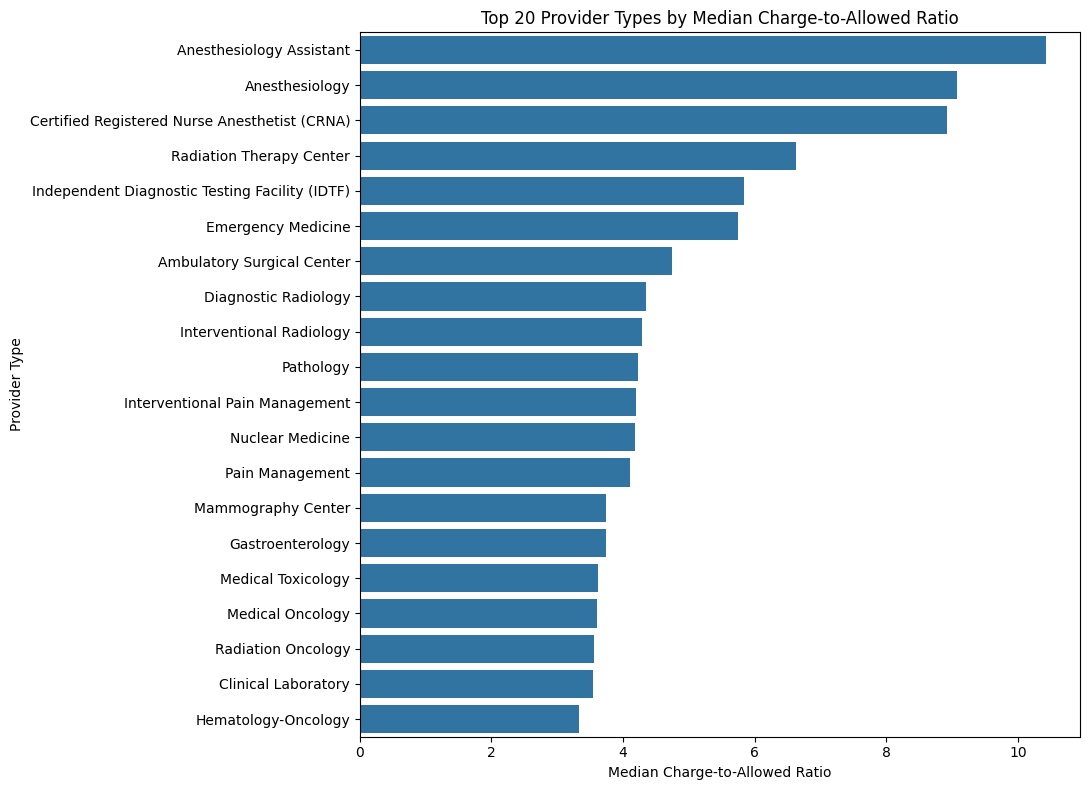

In [55]:
# Plot provider types with the highest median charge-to-allowed ratios using seaborn

plot_df = top_charge_allowed_ratio.reset_index()
plot_df.columns = ["provider_type", "charge_to_allowed_ratio"]

plt.figure(figsize=(11, 8))
sns.barplot(data=plot_df, x="charge_to_allowed_ratio", y="provider_type")

plt.title("Top 20 Provider Types by Median Charge-to-Allowed Ratio")
plt.xlabel("Median Charge-to-Allowed Ratio")
plt.ylabel("Provider Type")
plt.tight_layout()
plt.show()

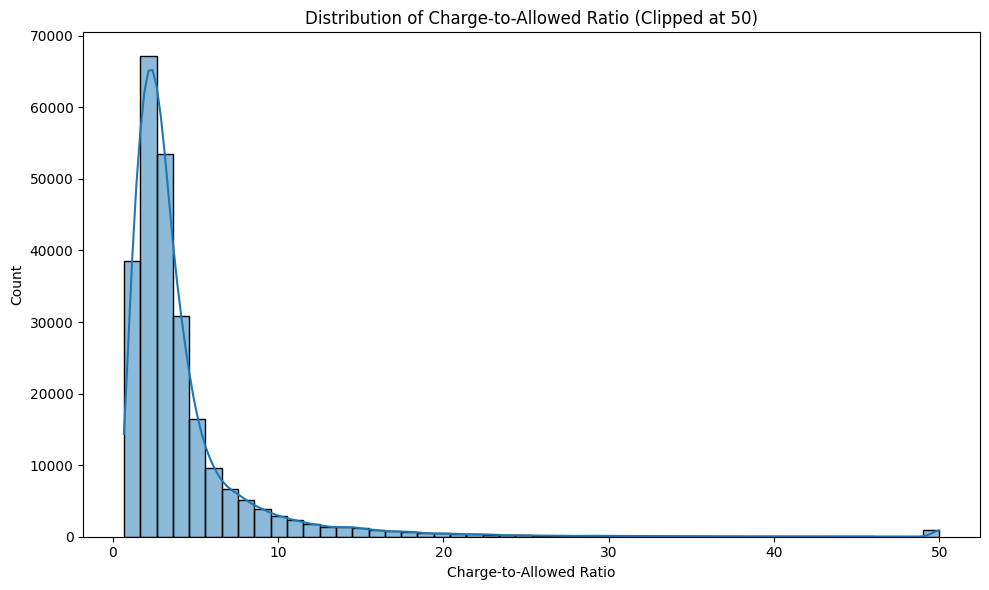

In [56]:
# Plot the distribution of charge-to-allowed ratio to inspect reimbursement friction outliers

plt.figure(figsize=(10, 6))
sns.histplot(sample_df["charge_to_allowed_ratio"].clip(upper=50), bins=50, kde=True)

plt.title("Distribution of Charge-to-Allowed Ratio (Clipped at 50)")
plt.xlabel("Charge-to-Allowed Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

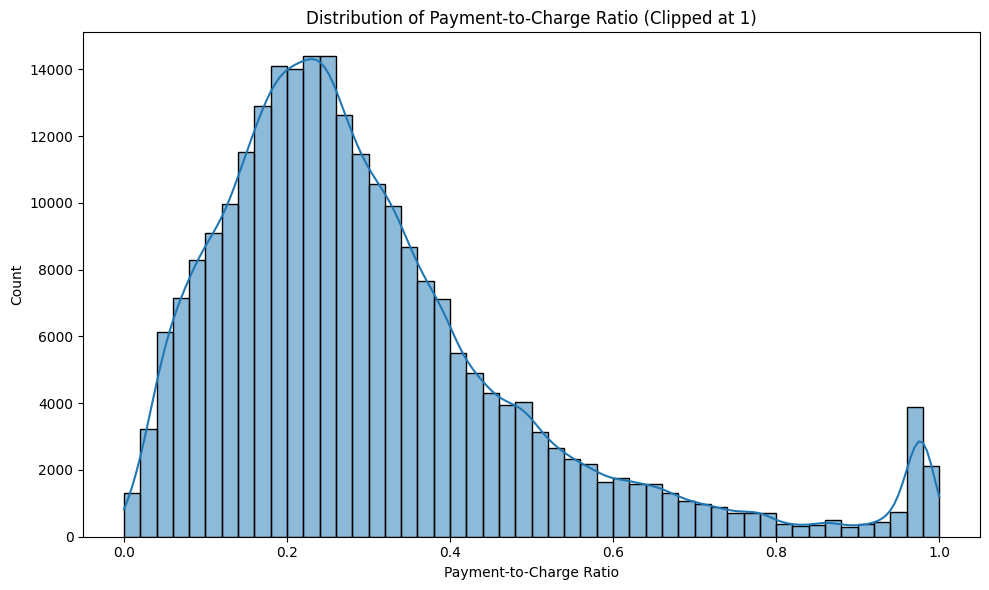

In [57]:
# Plot the distribution of payment-to-charge ratio to inspect how much submitted charges are paid

plt.figure(figsize=(10, 6))
sns.histplot(sample_df["payment_to_charge_ratio"].clip(upper=1), bins=50, kde=True)

plt.title("Distribution of Payment-to-Charge Ratio (Clipped at 1)")
plt.xlabel("Payment-to-Charge Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [58]:
# Identify the top 20 HCPCS codes by total service volume

top_hcpcs_services = (
    sample_df.groupby(["hcpcs_code", "hcpcs_description"])["total_services"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_hcpcs_services

hcpcs_code  hcpcs_description                                                                                                                                                                    
P9603       Travel allowance one way in connection with medically necessary laboratory specimen collection drawn from home bound or nursing home bound patient; prorated miles actually travelled    3390769.7
Q9967       Low osmolar contrast material, 300-399 mg/ml iodine concentration, per ml                                                                                                                2698308.5
99214       Established patient office or other outpatient visit with moderate level of decision making, if using time, 30 minutes or more                                                           2589222.0
A0425       Ground mileage, per statute mile                                                                                                                                             

In [59]:
# Identify HCPCS codes with the highest median charge-to-allowed ratios

top_hcpcs_ratio = (
    sample_df.groupby(["hcpcs_code", "hcpcs_description"])["charge_to_allowed_ratio"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

top_hcpcs_ratio

hcpcs_code  hcpcs_description                                                                                                               
0827T       Digitization of glass microscope slides for cytopathology of fluids, washings, or brushings, smears                                 7000.000000
31623       Exam of lung airways using an endoscope                                                                                             4686.181278
0752T       Digitization of glass microscope slides for level iii surgical pathology                                                            3307.692308
0753T       Digitization of glass microscope slides for level iv surgical pathology                                                              800.500000
J0133       Injection, acyclovir, 5 mg                                                                                                           296.226415
J2001       Injection, lidocaine hcl for intravenous infusion, 10 mg           

In [60]:
# Create a proxy denial-risk label using reimbursement friction signals

sample_df["high_charge_allowed_ratio"] = (
    sample_df["charge_to_allowed_ratio"] >= sample_df["charge_to_allowed_ratio"].quantile(0.75)
).astype(int)

sample_df["low_payment_charge_ratio"] = (
    sample_df["payment_to_charge_ratio"] <= sample_df["payment_to_charge_ratio"].quantile(0.25)
).astype(int)

sample_df["high_service_intensity"] = (
    sample_df["services_per_beneficiary"] >= sample_df["services_per_beneficiary"].quantile(0.75)
).astype(int)

sample_df["risk_score"] = (
    sample_df["high_charge_allowed_ratio"]
    + sample_df["low_payment_charge_ratio"]
    + sample_df["high_service_intensity"]
)

sample_df["denial_risk_proxy"] = np.where(sample_df["risk_score"] >= 2, 1, 0)

sample_df[[
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "services_per_beneficiary",
    "risk_score",
    "denial_risk_proxy"
]].head()

,charge_to_allowed_ratio,payment_to_charge_ratio,services_per_beneficiary,risk_score,denial_risk_proxy
81501,3.868406,0.258504,1.000000,0,0
9712682,3.082614,0.324400,1.000000,0,0
7413171,7.966044,0.097050,1.000000,2,1
2010979,1.174675,0.678275,1.339286,0,0
290418,2.673829,0.283305,11.909091,1,0


## Proxy Denial-Risk Label

In [61]:
# Check the class counts for the proxy denial-risk label

sample_df["denial_risk_proxy"].value_counts()

denial_risk_proxy
0    190698
1     59302
Name: count, dtype: int64

In [62]:
# Check the percentage split between low-risk and high-risk proxy labels

sample_df["denial_risk_proxy"].value_counts(normalize=True)

denial_risk_proxy
0    0.762792
1    0.237208
Name: proportion, dtype: float64

In [63]:
# Compare reimbursement metrics by proxy denial-risk label

risk_summary = (
    sample_df.groupby("denial_risk_proxy")[[
        "charge_to_allowed_ratio",
        "payment_to_charge_ratio",
        "payment_to_allowed_ratio",
        "services_per_beneficiary",
        "avg_submitted_charge",
        "avg_medicare_payment_amount"
    ]]
    .median()
    .round(3)
)

risk_summary

,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary,avg_submitted_charge,avg_medicare_payment_amount
denial_risk_proxy,,,,,,
0,2.502,0.308,0.780,1.09,156.324,55.313
1,7.211,0.108,0.785,1.04,400.000,42.015


In [64]:
# Save the final 250k modeling dataset with engineered features and proxy denial-risk label

modeling_csv_path = PROCESSED_DATA_DIR / "denial_risk_modeling_sample_250k.csv"
modeling_parquet_path = PROCESSED_DATA_DIR / "denial_risk_modeling_sample_250k.parquet"

sample_df.to_csv(modeling_csv_path, index=False)
sample_df.to_parquet(modeling_parquet_path, index=False)

print(f"Saved modeling CSV to: {modeling_csv_path}")
print(f"Saved modeling Parquet to: {modeling_parquet_path}")

Saved modeling CSV to: ..\data\processed\denial_risk_modeling_sample_250k.csv
Saved modeling Parquet to: ..\data\processed\denial_risk_modeling_sample_250k.parquet
